In [140]:
import pandas as pd
import numpy as np

import datetime
from collections import Counter

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from tensorflow.keras.losses import Huber
from scipy.stats import zscore

In [141]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train['source']='train'
test['source']='test'
df_train = pd.concat([train, test],ignore_index=True)

print(train.shape, test.shape, df_train.shape)

Outlet_Identifier = df_train['Outlet_Identifier']

(8523, 13) (5681, 12) (14204, 13)


In [142]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,train
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,train
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,train
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,train
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,train


In [143]:
from scipy.stats import mstats
#df_train['Item_Outlet_Sales'] = mstats.winsorize(df_train['Item_Outlet_Sales'], limits=[0.0, 0.01])

In [144]:
def impute_values(df_train):

    avg_val = {}

    for idx in range(df_train.shape[0]):
      ky = df_train.iloc[idx]['Item_Identifier']

      if pd.isna(df_train.iloc[idx]['Item_Weight']):
        continue

      if ky not in avg_val:
        avg_val[ky] = [0, 0]

      avg_val[ky][0] += df_train.iloc[idx]['Item_Weight']
      avg_val[ky][1] += 1

    for ky in avg_val:
      avg_val[ky] = avg_val[ky][0]/avg_val[ky][1]

    df_train['Item_Weight'] = df_train.apply(
    lambda row: avg_val[row['Item_Identifier']] if pd.isna(row['Item_Weight']) else row['Item_Weight'],
    axis=1
    )

    cat_col = 'Outlet_Size'

    le = LabelEncoder()

    # Temporarily encode non-null values
    df_non_null = df_train[cat_col].dropna()
    le.fit(df_non_null)

    # Apply encoding (NaN will remain NaN)
    df_train[cat_col + '_encoded'] = df_train[cat_col].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)

    le = LabelEncoder()

    # Temporarily encode non-null values
    df_non_null = df_train[cat_col].dropna()
    le.fit(df_non_null)

    # Apply encoding (NaN will remain NaN)
    df_train[cat_col + '_encoded'] = df_train[cat_col].map(lambda x: le.transform([x])[0] if pd.notna(x) else np.nan)

    # Select columns to use for imputation (must be numeric)
    cols_for_imputation = ['Item_Weight', 'Item_MRP', cat_col + '_encoded']  # Include relevant predictors

    imputer = KNNImputer(n_neighbors=5)
    df_imputed = imputer.fit_transform(df_train[cols_for_imputation])

    # Replace the encoded column with imputed values
    df_train[cat_col + '_encoded'] = df_imputed[:, cols_for_imputation.index(cat_col + '_encoded')]

    # Round imputed values to nearest integer (since it represents category index)
    df_train[cat_col + '_encoded'] = df_train[cat_col + '_encoded'].round().astype(int)

    # Decode back to original category
    df_train[cat_col] = le.inverse_transform(df_train[cat_col + '_encoded'])
    df_train = df_train.drop(columns=[cat_col+'_encoded'])

    return df_train

# Example usage
# df_tmp = impute_values(df_train)

In [145]:
outlet_sales = df_train['Item_Outlet_Sales']
source = df_train['source']

In [146]:
df_train = impute_values(df_train.drop(['Item_Outlet_Sales', 'source'], axis=1))

df_train['Item_Outlet_Sales'] = outlet_sales
df_train['source'] = source

In [147]:
# Calculate null rates for each column
null_rates = df_train.isnull().sum() / len(df_train) * 100
null_rates

,0
Item_Identifier,0.000000
Item_Weight,0.000000
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,0.000000
Outlet_Location_Type,0.000000


In [148]:
# Step 1: Count how many times each (Outlet_Identifier, Item_Type) pair occurs
count_df = df_train.groupby(['Outlet_Identifier', 'Item_Type']).size().reset_index(name='count')

# Step 2: Pivot to have Outlet_Identifier as rows, Item_Type as columns
count_pivot = count_df.pivot(index='Outlet_Identifier', columns='Item_Type', values='count').fillna(0)

# Step 3: Normalize each column so that sum of each Item_Type column is 1
sale_frac = count_pivot.div(count_pivot.sum(axis=0), axis=1)

# Show result
sale_frac.head()

Item_Type,Baking Goods,Breads,Breakfast,Canned,Dairy,Frozen Foods,Fruits and Vegetables,Hard Drinks,Health and Hygiene,Household,Meat,Others,Seafood,Snack Foods,Soft Drinks,Starchy Foods
Outlet_Identifier,,,,,,,,,,,,,,,,
OUT010,0.066298,0.072115,0.064516,0.060886,0.062500,0.065217,0.068058,0.069061,0.064103,0.067183,0.070652,0.064286,0.044944,0.061840,0.063361,0.063197
OUT013,0.109576,0.108173,0.107527,0.108856,0.109155,0.108696,0.109290,0.110497,0.109557,0.108527,0.108696,0.107143,0.112360,0.110608,0.110193,0.111524
OUT017,0.107735,0.105769,0.107527,0.108856,0.110035,0.108696,0.106806,0.110497,0.107226,0.109173,0.108696,0.107143,0.101124,0.110106,0.110193,0.111524
OUT018,0.109576,0.108173,0.107527,0.109779,0.109155,0.107994,0.108793,0.107735,0.107226,0.108527,0.105978,0.107143,0.112360,0.110106,0.110193,0.111524
OUT019,0.061694,0.067308,0.075269,0.060886,0.061620,0.067321,0.062593,0.052486,0.061772,0.060078,0.066576,0.078571,0.067416,0.058321,0.059229,0.044610


In [149]:
def get_sales_count(row):
  return sale_frac.loc[row['Outlet_Identifier'], row['Item_Type']]

df_train['Sales_Frac'] = df_train.apply(get_sales_count, axis=1)

In [150]:
def get_cost_unit_wt(row):
  return row['Item_MRP']/row['Item_Weight']

df_train['Per_Unit_Cost'] = df_train.apply(get_cost_unit_wt, axis=1)

df_train['Per_Unit_Cost'] = zscore(df_train['Per_Unit_Cost'])
df_train['Per_Unit_Cost'] = pd.cut(df_train['Per_Unit_Cost'], bins=[-float('inf'), -0.5,
                                                         0.5, float('inf')],
                              labels=['cheap', 'affordable', 'expensive'])

In [151]:
df_train['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,9294
Grocery Store,1805
Supermarket Type3,1559
Supermarket Type2,1546


In [152]:
df_train['Item_Type'].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [153]:
essentials = set(['Dairy', 'Meat', 'Fruits and Vegetables', 'Household', 'Breakfast',
                  'Health and Hygiene', 'Breads', 'Starchy Foods', 'Seafood'])

df_train['Essentials'] = df_train['Item_Type'].apply(lambda x: 1 if x in essentials else 0)

In [154]:
can_spoil = set(['Dairy', 'Meat', 'Fruits and Vegetables', 'Snack Foods', 'Breakfast',
             'Breads', 'Seafood'])

df_train['Can_Spoil'] = df_train['Item_Type'].apply(lambda x: 1 if x in can_spoil else 0)

In [155]:
df_train['Outlet_Identifier_en'] = df_train['Outlet_Identifier']

In [156]:
# prompt: get avg mrp of each item each item is uniquely identified by col Item_Identifier and then create a col sayin if the mrp if above , equal or below the avg mrp

# Calculate the average MRP for each item
avg_mrp = df_train.groupby('Item_Identifier')['Item_MRP'].mean()

# Create a new column 'MRP_Category' based on the average MRP
def categorize_mrp(row):
    item_identifier = row['Item_Identifier']
    item_mrp = row['Item_MRP']
    average_mrp = avg_mrp[item_identifier]
    if item_mrp > average_mrp:
        return 'Above Average'
    elif item_mrp < average_mrp:
        return 'Below Average'
    else:
        return 'Average'

df_train['MRP_Category'] = df_train.apply(categorize_mrp, axis=1)


In [157]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source,Sales_Frac,Per_Unit_Cost,Essentials,Can_Spoil,Outlet_Identifier_en,MRP_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,train,0.109155,expensive,1,1,OUT049,Above Average
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,train,0.110193,cheap,0,0,OUT018,Below Average
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,train,0.105978,cheap,1,1,OUT049,Above Average
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,train,0.068058,affordable,1,1,OUT010,Below Average
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,train,0.108527,cheap,1,0,OUT013,Below Average


In [158]:
#df_train['Item_Subcategory'] = df_train['Item_Identifier'].str[2]

visibility_avg = df_train.pivot_table(values='Item_Visibility', index='Item_Identifier')

#Impute 0 values with mean visibility of that product:
miss_bool = (df_train['Item_Visibility'] == 0)
df_train.loc[miss_bool,'Item_Visibility'] = df_train.loc[miss_bool,'Item_Identifier'].apply(lambda x: visibility_avg.loc[x])
df_train['Item_Visibility_MeanRatio'] = df_train.apply(lambda x: x['Item_Visibility']/visibility_avg.loc[x['Item_Identifier']], axis=1)

#Get the first two characters of ID:
df_train['Item_Type_Combined'] = df_train['Item_Identifier'].apply(lambda x: x[0:2])
#Rename them to more intuitive categories:
df_train['Item_Type_Combined'] = df_train['Item_Type_Combined'].map({'FD':'Food',
                                                             'NC':'Non-Consumable',
                                                             'DR':'Drinks'})

fat_content_map = {'Low Fat': 'Low Fat', 'low fat': 'Low Fat',
                   'Regular': 'Regular', 'LF': 'Low Fat', 'reg': 'Regular'}

def process_fat_content(x):
  return fat_content_map[x]

df_train['Item_Fat_Content'] = df_train['Item_Fat_Content'].apply(process_fat_content)
df_train.loc[df_train['Item_Type_Combined']=="Non-Consumable",'Item_Fat_Content'] = "Non-Edible"

# categorical maps
# One hot encode Item type, outlet_type, fat content

outlet_size_map = {'Medium': 1, 'High': 2, 'Small': 0}
outlet_location_type = {'Tier 1': 2, 'Tier 3': 0, 'Tier 2': 1}
outlet_id_map = {'OUT049': 0, 'OUT018': 1, 'OUT010': 2, 'OUT013': 3, 'OUT027': 4,
                 'OUT045': 5, 'OUT017': 6, 'OUT046': 7, 'OUT035': 8, 'OUT019': 9}

df_train['Outlet_Size'] = df_train['Outlet_Size'].apply(lambda x: outlet_size_map[x])
df_train['Outlet_Location_Type'] = df_train['Outlet_Location_Type'].apply(lambda x: outlet_location_type[x])
#df_train['Outlet_Identifier_en'] = df_train['Outlet_Identifier'].apply(lambda x: outlet_id_map[x])

curr_year = 2013
df_train['Outlet_Age'] = curr_year - df_train['Outlet_Establishment_Year']

#drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year']
drop_cols = ['Outlet_Establishment_Year', 'Item_Visibility', 'Item_Type']
df_train = df_train.drop(columns=drop_cols, axis=1)

def encode_categorical_cols(df):
    # Identify categorical columns
    categorical_cols = ['Outlet_Type', 'Item_Fat_Content',
                        'Item_Type_Combined', 'Per_Unit_Cost',
                        'MRP_Category', 'Outlet_Identifier_en']

    # Perform One-Hot Encoding on categorical columns
    df = pd.get_dummies(df, columns=categorical_cols)

    return df

df_train = encode_categorical_cols(df_train)

def scale_values(df, cols_to_scale, scaler=None):
    """
    Scales the specified columns in a DataFrame using Standard Scaling (Z-score scaling).

    Parameters:
    - df: pandas DataFrame containing the data.
    - cols_to_scale: List of column names to scale.
    - scaler: Pre-fitted StandardScaler object. If None, the scaler will be fitted on the data.

    Returns:
    - df_scaled: DataFrame with scaled values.
    - scaler: Fitted StandardScaler object.
    """

    if scaler is None:
        scaler = StandardScaler()
        # Fit the scaler on the training data and transform the specified columns
        df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    else:
        # Use the pre-fitted scaler to transform the test data
        df[cols_to_scale] = scaler.transform(df[cols_to_scale])

    return df, scaler

cols_to_scale = ['Item_Weight', 'Item_MRP',	'Outlet_Age', 'Per_Unit_Cost']
#df_train, scaler = scale_values(df_train, cols_to_scale)

'''
def log_transform(df, cols_to_transform):
    """
    Applies log transformation to the specified columns in the DataFrame.

    Parameters:
    - df: pandas DataFrame containing the data.
    - cols_to_transform: List of column names to apply log transformation.

    Returns:
    - df_transformed: DataFrame with log-transformed values.
    """

    for col in cols_to_transform:
        # Apply log transformation
        # Adding 1 to avoid log(0) issues, as log(0) is undefined
        df[col] = np.log(df[col] + 1)

    return df

def inverse_log_transform(log_tr):
    return np.exp(log_tr) - 1

cols_to_transform = ['Item_Visibility', 'Item_Outlet_Sales']
#cols_to_transform = ['Item_Visibility']
df_train = log_transform(df_train, cols_to_transform)
'''

'\ndef log_transform(df, cols_to_transform):\n    """\n    Applies log transformation to the specified columns in the DataFrame.\n\n    Parameters:\n    - df: pandas DataFrame containing the data.\n    - cols_to_transform: List of column names to apply log transformation.\n\n    Returns:\n    - df_transformed: DataFrame with log-transformed values.\n    """\n\n    for col in cols_to_transform:\n        # Apply log transformation\n        # Adding 1 to avoid log(0) issues, as log(0) is undefined\n        df[col] = np.log(df[col] + 1)\n\n    return df\n\ndef inverse_log_transform(log_tr):\n    return np.exp(log_tr) - 1\n\ncols_to_transform = [\'Item_Visibility\', \'Item_Outlet_Sales\']\n#cols_to_transform = [\'Item_Visibility\']\ndf_train = log_transform(df_train, cols_to_transform)\n'

In [159]:
df_train.head()

,Item_Identifier,Item_Weight,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,source,Sales_Frac,Essentials,...,Outlet_Identifier_en_OUT010,Outlet_Identifier_en_OUT013,Outlet_Identifier_en_OUT017,Outlet_Identifier_en_OUT018,Outlet_Identifier_en_OUT019,Outlet_Identifier_en_OUT027,Outlet_Identifier_en_OUT035,Outlet_Identifier_en_OUT045,Outlet_Identifier_en_OUT046,Outlet_Identifier_en_OUT049
0,FDA15,9.30,249.8092,OUT049,1,2,3735.1380,train,0.109155,1,...,False,False,False,False,False,False,False,False,False,True
1,DRC01,5.92,48.2692,OUT018,1,0,443.4228,train,0.110193,0,...,False,False,False,True,False,False,False,False,False,False
2,FDN15,17.50,141.6180,OUT049,1,2,2097.2700,train,0.105978,1,...,False,False,False,False,False,False,False,False,False,True
3,FDX07,19.20,182.0950,OUT010,1,0,732.3800,train,0.068058,1,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,53.8614,OUT013,2,0,994.7052,train,0.108527,1,...,False,True,False,False,False,False,False,False,False,False


In [160]:
df_train.to_csv('clean_data.csv', index=False)

In [161]:
df_train.shape

(14204, 39)

In [162]:
# prompt: given item 'Item_Visibility_MeanRatio' col I want to add 0.5 for large outlet_size, 0.3 for medium and 0.2 for small

# Add 0.5 for large outlet_size, 0.3 for medium and 0.2 for small
def adjust_visibility(row):
    if row['Outlet_Size'] == 3:  # Assuming 3 represents 'High' (large)
        return row['Item_Visibility_MeanRatio'] + 0.5
    elif row['Outlet_Size'] == 2:  # Assuming 2 represents 'Medium'
        return row['Item_Visibility_MeanRatio'] + 0.3
    elif row['Outlet_Size'] == 1:  # Assuming 1 represents 'Small'
        return row['Item_Visibility_MeanRatio'] + 0.2
    else:
        return row['Item_Visibility_MeanRatio']  # Handle other cases or missing values

df_train['Item_Visibility_MeanRatio'] = df_train.apply(adjust_visibility, axis=1)


In [163]:
df_train['Outlet_Identifier'] = Outlet_Identifier
df_train.head()

,Item_Identifier,Item_Weight,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,source,Sales_Frac,Essentials,...,Outlet_Identifier_en_OUT010,Outlet_Identifier_en_OUT013,Outlet_Identifier_en_OUT017,Outlet_Identifier_en_OUT018,Outlet_Identifier_en_OUT019,Outlet_Identifier_en_OUT027,Outlet_Identifier_en_OUT035,Outlet_Identifier_en_OUT045,Outlet_Identifier_en_OUT046,Outlet_Identifier_en_OUT049
0,FDA15,9.30,249.8092,OUT049,1,2,3735.1380,train,0.109155,1,...,False,False,False,False,False,False,False,False,False,True
1,DRC01,5.92,48.2692,OUT018,1,0,443.4228,train,0.110193,0,...,False,False,False,True,False,False,False,False,False,False
2,FDN15,17.50,141.6180,OUT049,1,2,2097.2700,train,0.105978,1,...,False,False,False,False,False,False,False,False,False,True
3,FDX07,19.20,182.0950,OUT010,1,0,732.3800,train,0.068058,1,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,53.8614,OUT013,2,0,994.7052,train,0.108527,1,...,False,True,False,False,False,False,False,False,False,False


In [164]:
#Divide into test and train:
df_test = df_train.loc[df_train['source']=="test"]
df_train = df_train.loc[df_train['source']=="train"]

#Drop unnecessary columns:
df_test.drop(['Item_Outlet_Sales','source'], axis=1, inplace=True)
df_train.drop(['source'], axis=1, inplace=True)

<ipython-input-164-b48eb96b882d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['Item_Outlet_Sales','source'], axis=1, inplace=True)
<ipython-input-164-b48eb96b882d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.drop(['source'], axis=1, inplace=True)


In [165]:
target = 'Item_Outlet_Sales'
#IDcol = ['Item_Identifier','Outlet_Identifier']
IDcol = ['Item_Identifier', 'Outlet_Identifier']

df_train = df_train.drop(columns=IDcol, axis=1)

In [166]:
df_train.head()

,Item_Weight,Item_MRP,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Sales_Frac,Essentials,Can_Spoil,Item_Visibility_MeanRatio,Outlet_Age,...,Outlet_Identifier_en_OUT010,Outlet_Identifier_en_OUT013,Outlet_Identifier_en_OUT017,Outlet_Identifier_en_OUT018,Outlet_Identifier_en_OUT019,Outlet_Identifier_en_OUT027,Outlet_Identifier_en_OUT035,Outlet_Identifier_en_OUT045,Outlet_Identifier_en_OUT046,Outlet_Identifier_en_OUT049
0,9.30,249.8092,1,2,3735.1380,0.109155,1,1,1.131078,14,...,False,False,False,False,False,False,False,False,False,True
1,5.92,48.2692,1,0,443.4228,0.110193,0,0,1.133420,4,...,False,False,False,True,False,False,False,False,False,False
2,17.50,141.6180,1,2,2097.2700,0.105978,1,1,1.160069,14,...,False,False,False,False,False,False,False,False,False,True
3,19.20,182.0950,1,0,732.3800,0.068058,1,1,1.200000,15,...,True,False,False,False,False,False,False,False,False,False
4,8.93,53.8614,2,0,994.7052,0.108527,1,0,1.300000,26,...,False,True,False,False,False,False,False,False,False,False


In [167]:
def plot_predictions(prediction_data):
  keys = list(prediction_data)

  original_y = prediction_data[keys[0]]
  predicted_y = prediction_data[keys[1]]

  # Plotting
  plt.figure(figsize=(20,6))

  # Plot the original values
  plt.plot(original_y, label='Original Values',
           color='black', linestyle='-', marker='o')

  # Plot the predicted values
  plt.plot(predicted_y, label='Predicted Values', linestyle='--', marker='x')

  # Adding labels and title
  plt.xlabel('Original Values')
  plt.ylabel('Predicted Values')
  plt.title('Comparison of Original and Model Predictions')
  plt.legend()

  # Show the plot
  plt.grid(True)
  plt.show()

In [168]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def train_xgb_model_with_tuning(df, target_column='Item_Outlet_Sales',
                                test_size=0.2, random_state=42):
    """
    Trains an XGBoost Regressor with hyperparameter tuning.

    Returns:
    - best_model: Trained XGBoost model with best hyperparameters
    - X_test, y_test, y_pred: Test data and predictions
    - metrics: Evaluation results
    """

    # Split into X and y
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state)

    # Initial model
    model_xgb = XGBRegressor(random_state=random_state, n_jobs=-1)

    # Hyperparameter grid
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2, 0.5],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 1.5, 2]
    }

    # Randomized search
    random_search = RandomizedSearchCV(
        model_xgb, param_distributions=param_dist,
        n_iter=25,  # number of different combinations to try
        scoring='neg_root_mean_squared_error',
        cv=3,
        verbose=1,
        random_state=random_state,
        n_jobs=-1
    )

    # Fit search
    random_search.fit(X, y)

    # Best model
    model_xgb = random_search.best_estimator_

    # Predict
    y_pred = model_xgb.predict(X_test)

    prediction_data = {}
    prediction_data['Original_y'] = y_test.to_numpy()
    prediction_data['XgBoostBest_y'] = y_pred

    # Evaluate
    mse = mean_squared_error(prediction_data['Original_y'], prediction_data['XgBoostBest_y'])
    r2 = r2_score(prediction_data['Original_y'], prediction_data['XgBoostBest_y'])

    metrics = {'rmse': mse**0.5, 'r2_score': r2}

    return model_xgb, X_test, y_test, y_pred, metrics, random_search, prediction_data

In [169]:
model_xgb, X_test, y_test, y_pred, metrics, random_search, prediction_data = train_xgb_model_with_tuning(df_train)
metrics

Fitting 3 folds for each of 25 candidates, totalling 75 fits


{'rmse': 983.363777197292, 'r2_score': 0.6442181868811256}

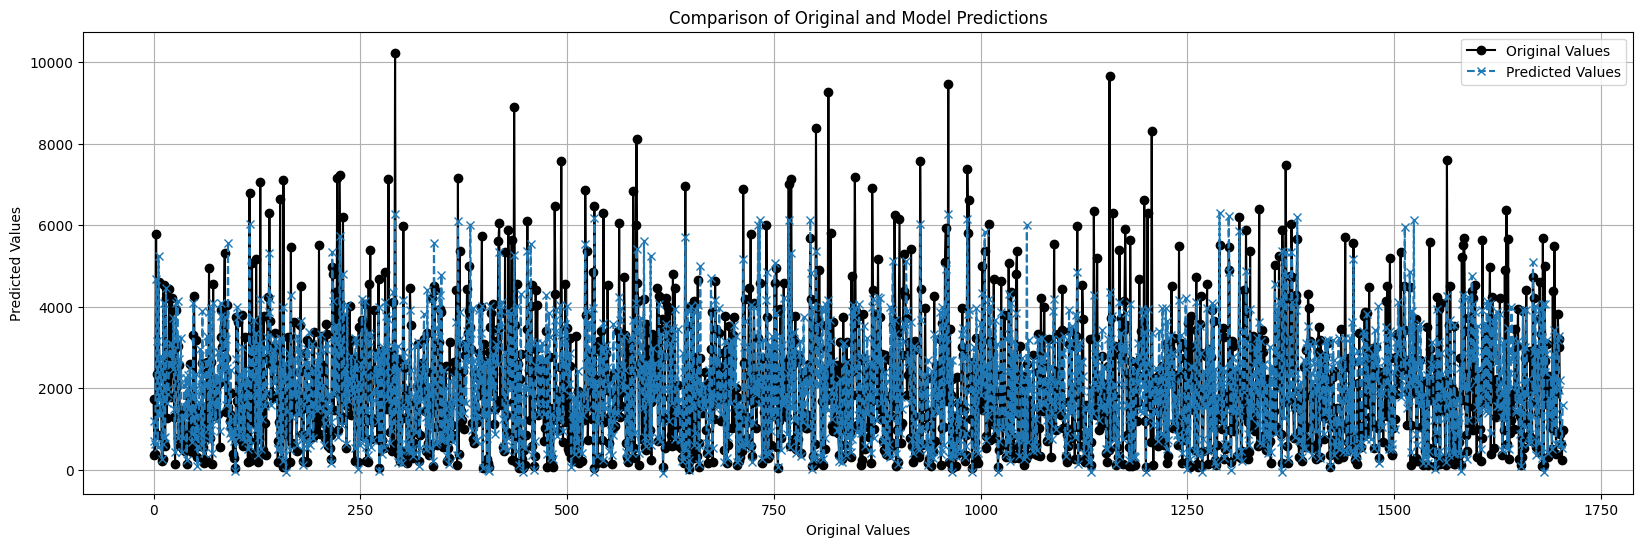

In [170]:
plot_predictions(prediction_data)

In [171]:
numeric_columns = ['Item_Visibility_MeanRatio', 'Outlet_Age', 'Item_Outlet_Sales',
                   'Sales_Frac']
'''
numeric_columns = ['Sales_Frac', 'Item_MRP', 'Outlet_Age', 'Outlet_Size',
                   'Item_Visibility_MeanRatio']
'''

'''
predictors = ['Outlet_Type_Supermarket Type3', 'Sales_Frac', 'Item_MRP',
              'Outlet_Age', 'Outlet_Type_Supermarket Type1', 'Per_Unit_Cost']
'''

categorical_columns = [col for col in df_train.columns if col not in numeric_columns]
#categorical_columns = [col for col in predictors if col not in numeric_columns]

In [172]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define target
target_column = 'Item_Outlet_Sales'

predictors = ['Outlet_Type_Supermarket Type3', 'Sales_Frac', 'Item_MRP',
              'Outlet_Age', 'Outlet_Type_Supermarket Type1', 'Outlet_Size',
              'Item_Visibility_MeanRatio', 'Per_Unit_Cost']

# Split into X and y
X = df_train.drop('Item_Outlet_Sales', axis=1)
# Split into X and y
#X = df_train.drop(columns=[target_column])
y = df_train[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# List of categorical columns (original columns before encoding)
categorical_cols = categorical_columns  # Make sure this is defined

# LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=categorical_cols)

# Define a parameter grid for tuning
param_grid = {
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'num_leaves': [20, 31, 40, 50, 70, 80, 100],
    'max_depth': [5, 7, 10, 15, 20, 25, 30, 35],
    'min_child_samples': [5, 10, 20, 30, 40],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.3, 0.5],
    'reg_lambda': [0, 0.1, 0.3, 0.5]
}

# Create a LightGBM Regressor for RandomizedSearchCV
lgbm = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    verbosity=-1,
    random_state=45
)

# Setup RandomizedSearchCV
rsearch = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=40,   # You can increase this for better search
    scoring='neg_root_mean_squared_error',  # RMSE
    cv=3,
    verbose=1,
    random_state=45,
    n_jobs=-1
)

# Perform Hyperparameter Tuning
rsearch.fit(X_train, y_train, categorical_feature=categorical_cols)

# Best Parameters
print("Best Parameters Found:\n", rsearch.best_params_)

# Train the final model with the best parameters
final_params = rsearch.best_params_
final_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 45
})

# Train again using lgb.train
final_train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
final_valid_data = lgb.Dataset(X_test, label=y_test, reference=final_train_data, categorical_feature=categorical_cols)

model_lgb = lgb.train(
    final_params,
    final_train_data,
    num_boost_round=5000,
    valid_sets=[final_train_data, final_valid_data],
    valid_names=['train', 'valid'],
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
)

# Predict
y_pred = model_lgb.predict(X_test, num_iteration=model_lgb.best_iteration)

prediction_data = {}
#prediction_data['Original_y'] = inverse_log_transform(y_test.to_numpy())
#prediction_data['LightGBM_y'] = inverse_log_transform(y_pred)
prediction_data['Original_y'] = y_test.to_numpy()
prediction_data['LightGBM_y'] = y_pred

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R2 Score: {r2:.5f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters Found:
 {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 20, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 997.79	valid's rmse: 1053.36
Early stopping, best iteration is:
[87]	train's rmse: 1008.28	valid's rmse: 1052.53
RMSE: 1052.53340
MAE: 737.73270
R2 Score: 0.59241


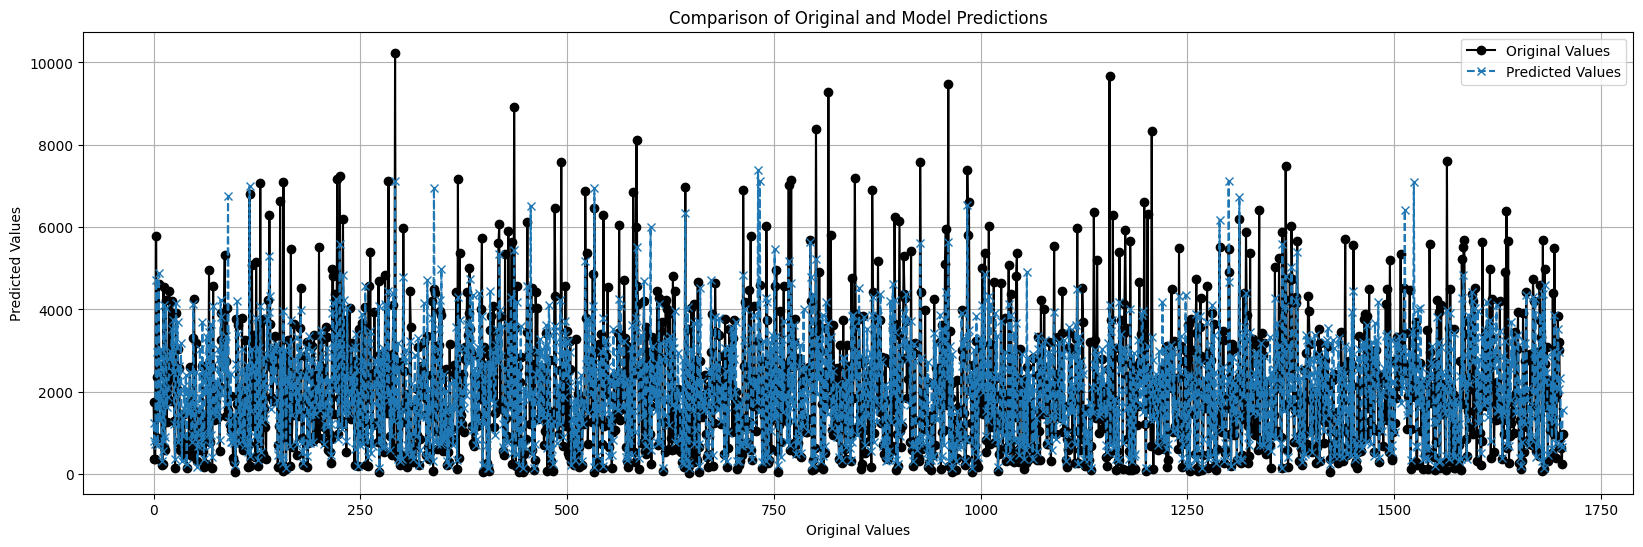

In [173]:
plot_predictions(prediction_data)

In [174]:
from xgboost import XGBRFRegressor

model_xgr = XGBRFRegressor()

target_column='Item_Outlet_Sales'

# Split into X and y
X = df_train.drop(columns=[target_column])
y = df_train[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                 random_state=42)
model_xgr.fit(X_train,y_train)
y_pred = model_xgr.predict(X_test)

prediction_data = {}
prediction_data['Original_y'] = y_test.to_numpy()
prediction_data['XGBRFRegressor_y'] = y_pred

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {'mse': mse**0.5, 'r2_score': r2}

In [175]:
# Get feature importance values
feature_importances = model_xgr.feature_importances_

# Combine with feature names
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Display
feature_importance_df

,Feature,Importance
9,Outlet_Type_Grocery Store,0.402886
12,Outlet_Type_Supermarket Type3,0.132735
30,Outlet_Identifier_en_OUT027,0.123136
4,Sales_Frac,0.094035
8,Outlet_Age,0.070436
1,Item_MRP,0.064670
19,Per_Unit_Cost_cheap,0.055684
11,Outlet_Type_Supermarket Type2,0.010508
10,Outlet_Type_Supermarket Type1,0.006058
23,MRP_Category_Average,0.005364


In [176]:
metrics

{'mse': 1021.5101389969964, 'r2_score': 0.6160800382277313}

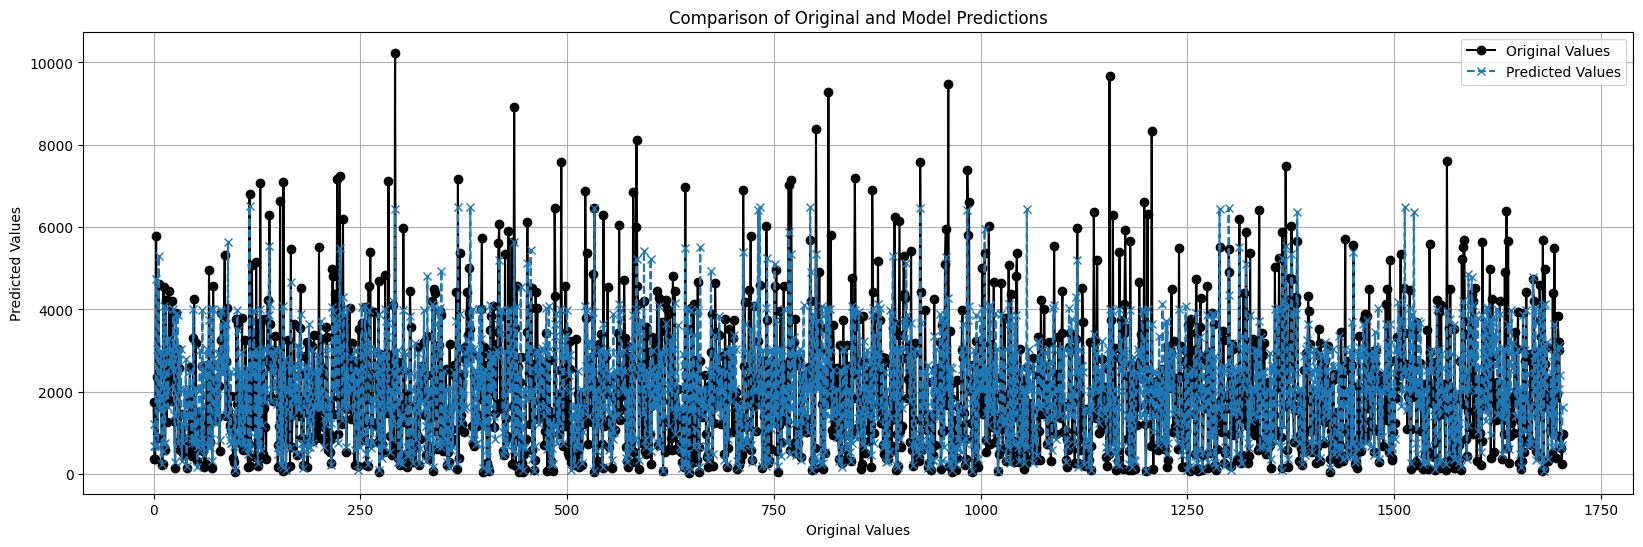

In [177]:
plot_predictions(prediction_data)

In [178]:
df_train.columns

Index(['Item_Weight', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type',
       'Item_Outlet_Sales', 'Sales_Frac', 'Essentials', 'Can_Spoil',
       'Item_Visibility_MeanRatio', 'Outlet_Age', 'Outlet_Type_Grocery Store',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3', 'Item_Fat_Content_Low Fat',
       'Item_Fat_Content_Non-Edible', 'Item_Fat_Content_Regular',
       'Item_Type_Combined_Drinks', 'Item_Type_Combined_Food',
       'Item_Type_Combined_Non-Consumable', 'Per_Unit_Cost_cheap',
       'Per_Unit_Cost_affordable', 'Per_Unit_Cost_expensive',
       'MRP_Category_Above Average', 'MRP_Category_Average',
       'MRP_Category_Below Average', 'Outlet_Identifier_en_OUT010',
       'Outlet_Identifier_en_OUT013', 'Outlet_Identifier_en_OUT017',
       'Outlet_Identifier_en_OUT018', 'Outlet_Identifier_en_OUT019',
       'Outlet_Identifier_en_OUT027', 'Outlet_Identifier_en_OUT035',
       'Outlet_Identifier_en_OUT045', 'Outle

In [179]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Define parameter space
param_dist = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],  # 'auto' removed
    'bootstrap': [True, False]
}

# Base model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                # number of different combinations to try
    cv=5,                     # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

predictors = ['Outlet_Type_Supermarket Type3', 'Outlet_Type_Grocery Store', 'Sales_Frac',
              'Outlet_Age', 'Item_MRP', 'Per_Unit_Cost_cheap', 'Outlet_Identifier_en_OUT027']

'''
predictors = ['Outlet_Type_Grocery Store', 'Outlet_Type_Supermarket Type3', 'Sales_Frac',
              'Outlet_Age', 'Item_MRP', 'MRP_Category_Average', 'Per_Unit_Cost_cheap']
'''
# Split into X and y
X = df_train[predictors]
y = df_train[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                 random_state=42)
# Fit search
random_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 5, 10, 20],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [100, 300, 500, 700]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [180]:
y_pred = random_search.predict(X_test)

prediction_data = {}
prediction_data['Original_y'] = y_test.to_numpy()
prediction_data['XGBRFRegressor_y'] = y_pred

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {'mse': mse**0.5, 'r2_score': r2}

In [181]:
metrics

{'mse': 969.2413444203739, 'r2_score': 0.6543638227395208}

In [182]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Reshape y_pred to 2D (required)
y_pred_reshaped = y_pred.reshape(-1, 1)

# Pipeline: Polynomial -> StandardScaler -> Ridge Regression
poly_ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=6, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.2))  # Regularization strength alpha (you can tune this)
])

# Fit pipeline
poly_ridge_pipeline.fit(y_pred_reshaped, y_test)

# Predict refined y
y_refined = poly_ridge_pipeline.predict(y_pred_reshaped)

# Evaluate new refined predictions
mse_refined = mean_squared_error(y_test, y_refined)
r2_refined = r2_score(y_test, y_refined)

metrics_refined = {'rmse_refined': mse_refined ** 0.5, 'r2_score_refined': r2_refined}

# Display
print(metrics_refined)

{'rmse_refined': 967.251567241221, 'r2_score_refined': 0.6557814944977725}


In [183]:
df_test

,Item_Identifier,Item_Weight,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Sales_Frac,Essentials,Can_Spoil,Item_Visibility_MeanRatio,...,Outlet_Identifier_en_OUT010,Outlet_Identifier_en_OUT013,Outlet_Identifier_en_OUT017,Outlet_Identifier_en_OUT018,Outlet_Identifier_en_OUT019,Outlet_Identifier_en_OUT027,Outlet_Identifier_en_OUT035,Outlet_Identifier_en_OUT045,Outlet_Identifier_en_OUT046,Outlet_Identifier_en_OUT049
8523,FDW58,20.750,107.8622,OUT049,1,2,0.110106,0,1,1.229192,...,False,False,False,False,False,False,False,False,False,True
8524,FDW14,8.300,87.3198,OUT017,1,1,0.110035,1,1,1.330311,...,False,False,True,False,False,False,False,False,False,False
8525,NCN55,14.600,241.7538,OUT010,0,0,0.064286,0,0,1.735215,...,True,False,False,False,False,False,False,False,False,False
8526,FDQ58,7.315,155.0340,OUT017,0,1,0.110106,0,1,1.291577,...,False,False,True,False,False,False,False,False,False,False
8527,FDY38,13.600,234.2300,OUT027,1,0,0.110035,1,1,1.117824,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDB58,10.500,141.3154,OUT046,0,2,0.108597,0,1,0.874729,...,False,False,False,False,False,False,False,False,True,False
14200,FDD47,7.600,169.1448,OUT018,1,0,0.111524,1,0,1.078292,...,False,False,False,True,False,False,False,False,False,False
14201,NCO17,10.000,118.7440,OUT045,1,1,0.109557,1,0,1.362245,...,False,False,False,False,False,False,False,True,False,False
14202,FDJ26,15.300,214.6218,OUT017,1,1,0.108856,0,0,1.200000,...,False,False,True,False,False,False,False,False,False,False


In [184]:
# 1️⃣ Base model predictions (already done)
df_test_pr = df_test[predictors]
y_pred = random_search.predict(df_test_pr)

# 2️⃣ Reshape for consistency
y_pred_base_new_reshaped = y_pred.reshape(-1, 1)

# 3️⃣ Use the pipeline directly for refined predictions
y_pred = poly_ridge_pipeline.predict(y_pred_base_new_reshaped)

In [185]:
y_pred

array([1704.8687091 , 1418.86761365,  523.88368166, ..., 1755.84869853,
       3978.77938174, 1268.26547324])

In [186]:
df_test['Predictions'] = y_pred

df_test_res = df_test[['Item_Identifier', 'Outlet_Identifier', 'Predictions']]
df_test_res = df_test_res.rename(columns={'Predictions': 'Item_Outlet_Sales'})

df_test_res['Item_Outlet_Sales'] = df_test_res['Item_Outlet_Sales'].apply(lambda x: abs(x))

df_test_res.to_csv('Result.csv', index=False)